In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [3]:
df = pd.read_csv('data.csv')

In [4]:
attributes = ['speechiness', 'acousticness', 'liveness', 'danceability', 'valence', 'instrumentalness']

In [5]:
mozart_row = df[df['name'] == 'Requiem In D Minor, K. 626: Sequence: VI. Lacrimosa Dies Illa']

mozart = pd.DataFrame()
for attribute in attributes:
    mozart[attribute] = mozart_row[attribute]
mozart['title'] = "Mozart's Requiem In D Minor, K. 626"
mozart

,speechiness,acousticness,liveness,danceability,valence,instrumentalness,title
134698,0.0418,0.957,0.568,0.0733,0.0731,0.644,"Mozart's Requiem In D Minor, K. 626"


In [6]:
toxic_row = df[df['name'] == 'Toxic'].iloc[[0]]

toxic = pd.DataFrame()
for attribute in attributes:
    toxic[attribute] = toxic_row[attribute]
toxic['title'] = 'Toxic by Britney Spears'
toxic

,speechiness,acousticness,liveness,danceability,valence,instrumentalness,title
16210,0.114,0.0249,0.242,0.774,0.924,0.025,Toxic by Britney Spears


In [7]:
hurt_row = df[df['name'] == 'Hurt'].iloc[[1]]

hurt = pd.DataFrame()
for attribute in attributes:
    hurt[attribute] = hurt_row[attribute]
hurt['title'] = 'Hurt by Johnny Cash'

In [8]:
songs = pd.concat([mozart, toxic, hurt]).groupby(["title"], as_index=False)[attributes].sum()
songs

,title,speechiness,acousticness,liveness,danceability,valence,instrumentalness
0,Hurt by Johnny Cash,0.0267,0.6490,0.0948,0.5340,0.1630,0.000227
1,"Mozart's Requiem In D Minor, K. 626",0.0418,0.9570,0.5680,0.0733,0.0731,0.644000
2,Toxic by Britney Spears,0.1140,0.0249,0.2420,0.7740,0.9240,0.025000


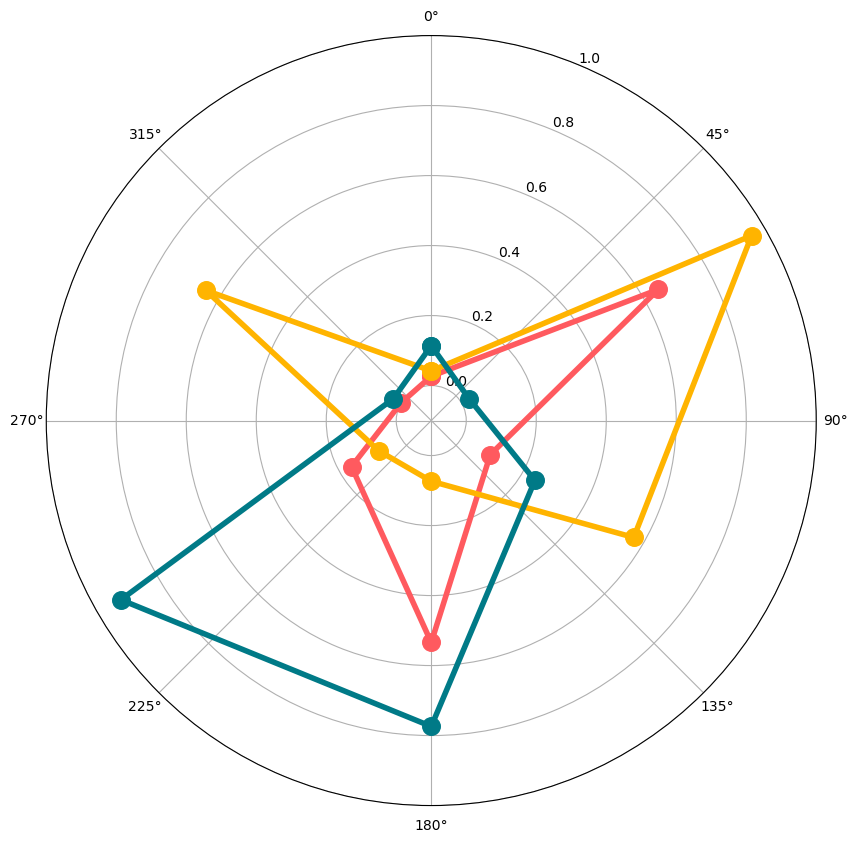

In [9]:
COLORS = ["#FF5A5F", "#FFB400", "#007A87"]

# The labels and variables to plot
titles = songs["title"].values.tolist()
VARIABLES = songs.columns.tolist()[1:]
VARIABLES_N = len(VARIABLES)

# The angles at which the values of the numeric variables are placed
ANGLES = [n / VARIABLES_N * 2 * np.pi for n in range(VARIABLES_N)]
ANGLES += ANGLES[:1]   

# Angle values going from 0 to 2*pi
HANGLES = np.linspace(0, 2 * np.pi)

# Used for the equivalent of horizontal lines in cartesian coordinates plots 
H0 = np.zeros(len(HANGLES))
H1 = np.ones(len(HANGLES)) * 0.5
H2 = np.ones(len(HANGLES))

# Initialize layout
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_ylim(-0.1, 1)

# Plot lines and dots
for idx, title in enumerate(titles):
    values = songs.iloc[idx].drop("title").values.tolist()
    values += values[:1]
    ax.plot(ANGLES, values, c=COLORS[idx], linewidth=4, label=title)
    ax.scatter(ANGLES, values, s=160, c=COLORS[idx], zorder=10)

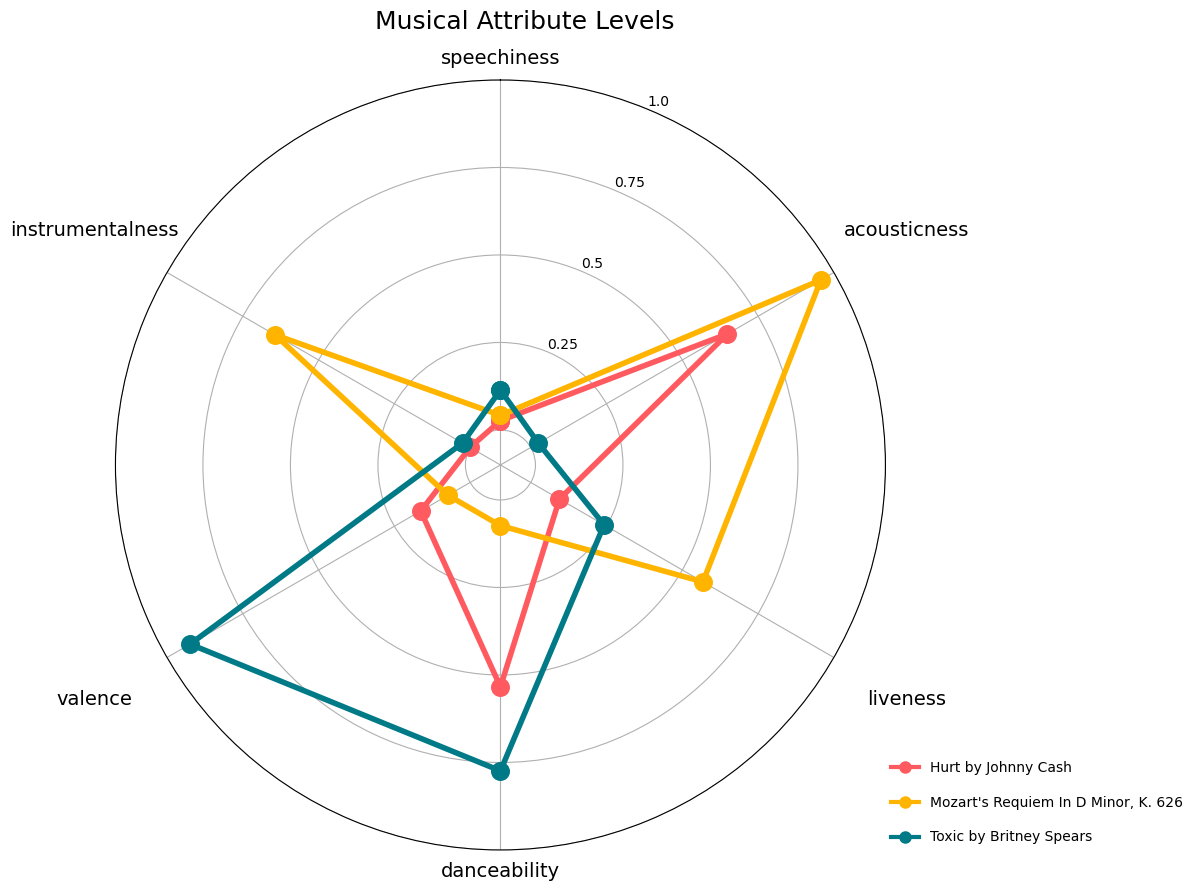

In [10]:
# Clean up x and y axes and set titles and legend
ax.set_xticks(ANGLES[:-1])
ax.set_xticklabels(VARIABLES, size=14)

ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels([None, 0.25, 0.5, 0.75, 1.0])

X_VERTICAL_TICK_PADDING = 5
X_HORIZONTAL_TICK_PADDING = 50 
XTICKS = ax.xaxis.get_major_ticks()    
for tick in XTICKS[0:6]:
    tick.set_pad(X_HORIZONTAL_TICK_PADDING)
for tick in XTICKS[0::3]:
    tick.set_pad(X_VERTICAL_TICK_PADDING)

fig.suptitle(
    "Musical Attribute Levels",
    x = 0.53, y = .95, fontsize = 18,
)

handles = [
    Line2D([], [], c=color, lw=3, marker="o", markersize=8, label=title)
    for title, color in zip(titles, COLORS)
]

legend = ax.legend(
    handles=handles,
    loc=(1, 0),       
    labelspacing=1.5, 
    frameon=False    
)

fig